In [7]:
# Setup
import numpy as np
import pyvista as pv
pv.set_jupyter_backend('static')
import matplotlib.pyplot as plt
from scipy.io import loadmat
from gravity_forward_numba import VecWerSch_numba, green_third_identity_potential_numba
import time

In [8]:
# Parameters
radii = [18, 20, 25, 30]          # Evaluation sphere radii (km)
icosph_level = 5                  # 10 * 4^n + 2
sub_lvls = list(range(7))         # Mesh refinement levels
rho = 2670.0                      # Density (kg/m^3)

In [9]:
# Load EROS shape model from MAT file
print("=== Loading EROS Geometry ===")
eros_mat = loadmat('EROS.mat')
eros_vf = eros_mat['eros856_1708']  # First nV rows: vertices; last nF rows: faces
nF = 1708
nVpF = eros_vf.shape[0]
nV = nVpF - nF

Verts = eros_vf[:nV, :].astype(np.float64)
Faces = eros_vf[nV:, :].astype(np.int64)

# Bounding box (in km)
X1, X2 = Verts[:, 0].min(), Verts[:, 0].max()
Y1, Y2 = Verts[:, 1].min(), Verts[:, 1].max()
Z1, Z2 = Verts[:, 2].min(), Verts[:, 2].max()

print(f"Number of vertices : {nV}")
print(f"Number of faces    : {nF}")
print(f"Bounding box (km)  :")
print(f"  X ∈ [{X1:8.4f}, {X2:8.4f}]")
print(f"  Y ∈ [{Y1:8.4f}, {Y2:8.4f}]")
print(f"  Z ∈ [{Z1:8.4f}, {Z2:8.4f}]")

# Create base PyVista mesh
pv_faces = np.column_stack([np.full(nF, 3, dtype=np.int32), Faces])
eros_base = pv.PolyData(Verts, pv_faces)

=== Loading EROS Geometry ===
Number of vertices : 856
Number of faces    : 1708
Bounding box (km)  :
  X ∈ [-17.5781,  15.0322]
  Y ∈ [ -8.2385,   8.4307]
  Z ∈ [ -6.0127,   5.8588]


In [10]:
# Generate evaluation points on concentric spheres (one per radius)
eval_pts_Rs = []
for r in radii:
    sphere_unit = pv.Icosphere(radius=1.0, nsub=icosph_level)
    pts = sphere_unit.points * r
    eval_pts_Rs.append(pts)

In [11]:
# Compute reference (exact) gravity potential on each evaluation sphere
print("\nComputing exact gravity potential on evaluation spheres...")
V_exact_Rs = []
t0_total = time.time()

for i, (r, pts) in enumerate(zip(radii, eval_pts_Rs)):
    t0 = time.time()
    V_exact, *_ = VecWerSch_numba(pts, Verts, Faces, rho)
    t_elapsed = time.time() - t0
    V_exact_Rs.append(V_exact)
    print(f" -> Radius {r} km: {len(pts)} points, time = {t_elapsed:.3f} s")

t_total = time.time() - t0_total
print(f"Total time for exact potential computation: {t_total:.3f} s")


Computing exact gravity potential on evaluation spheres...
 -> Radius 18 km: 10242 points, time = 0.058 s
 -> Radius 20 km: 10242 points, time = 0.051 s
 -> Radius 25 km: 10242 points, time = 0.051 s
 -> Radius 30 km: 10242 points, time = 0.053 s
Total time for exact potential computation: 0.214 s


In [12]:
# Convergence study: loop over mesh refinement levels
converg_summary = []  # Store error metrics per refinement level
for level in sub_lvls:
    print(f"\nProcessing subdivision level: {level}")
    
    # Refine mesh
    if level == 0:
        eros_sub = eros_base.copy()
    else:
        eros_sub = eros_base.subdivide(level, subfilter='linear')
    
    n_faces = eros_sub.n_cells
    print(f" -> Mesh has {n_faces} faces")

    # Extract face geometry
    face_centers = eros_sub.cell_centers().points
    face_normals = eros_sub.face_normals
    face_areas = eros_sub.compute_cell_sizes()["Area"]

    # Compute exact field on face centers (for Green's identity)
    t0 = time.time()
    V_face, gx_face, gy_face, gz_face, *_ = VecWerSch_numba(face_centers, Verts, Faces, rho)
    g_face = np.column_stack((gx_face, gy_face, gz_face))
    t_face = time.time() - t0
    print(f" -> Time (Face center field): {t_face:.3f} s")

    # Evaluate Green's third identity potential on each sphere
    V_green_Rs = []
    t_green_total = 0.0
    for pts in eval_pts_Rs:
        t0 = time.time()
        V_green = green_third_identity_potential_numba(
            face_centers, face_normals, face_areas, V_face, g_face, pts
        )
        t_green_total += time.time() - t0
        V_green_Rs.append(V_green)
    print(f" -> Time (Green's Third ID):  {t_green_total:.3f} s")

    # Compute relative errors
    rel_rms_errors = []
    rel_max_errors = []
    for i in range(len(radii)):
        V_exact = V_exact_Rs[i]
        V_green = V_green_Rs[i]
        diff = V_green - V_exact

        rms_diff = np.sqrt(np.mean(diff**2))
        rms_exact = np.sqrt(np.mean(V_exact**2))
        rel_rms = rms_diff / rms_exact
        rel_max = np.max(np.abs(diff/V_exact))

        rel_rms_errors.append(rel_rms)
        rel_max_errors.append(rel_max)

    converg_summary.append({
        'level': level,
        'n_faces': n_faces,
        'rel_rms': rel_rms_errors,
        'rel_max': rel_max_errors
    })


Processing subdivision level: 0
 -> Mesh has 1708 faces
 -> Time (Face center field): 0.015 s
 -> Time (Green's Third ID):  0.028 s

Processing subdivision level: 1
 -> Mesh has 6832 faces
 -> Time (Face center field): 0.034 s
 -> Time (Green's Third ID):  0.080 s

Processing subdivision level: 2
 -> Mesh has 27328 faces
 -> Time (Face center field): 0.130 s
 -> Time (Green's Third ID):  0.307 s

Processing subdivision level: 3
 -> Mesh has 109312 faces
 -> Time (Face center field): 0.500 s
 -> Time (Green's Third ID):  1.201 s

Processing subdivision level: 4
 -> Mesh has 437248 faces
 -> Time (Face center field): 2.291 s
 -> Time (Green's Third ID):  5.110 s

Processing subdivision level: 5
 -> Mesh has 1748992 faces
 -> Time (Face center field): 8.567 s
 -> Time (Green's Third ID):  34.056 s

Processing subdivision level: 6
 -> Mesh has 6995968 faces
 -> Time (Face center field): 35.565 s
 -> Time (Green's Third ID):  257.303 s


In [13]:
# Print convergence table
print("\n" + "="*92)
print("Convergence of Green's Third Identity Approximation")
print("Relative RMS and Maximum Errors vs. Eros Mesh Refinement")
print("="*92)

header1 = f"{'Level':>6} {'Faces':>8}" + "".join([f" {'RMS':>12} {'Max':>12}" for _ in radii])
header2 = " " * 15 + "".join([(" " * 10 + f"{r} km".center(16)) for r in radii])
print(header1)
print(header2)
print("-"*92)

for lvl_summary in converg_summary:
    level = lvl_summary['level']
    n_faces = lvl_summary['n_faces']
    row = f"{level:6d} {n_faces:8d}"
    for i in range(len(radii)):
        rms = lvl_summary['rel_rms'][i]
        rmx = lvl_summary['rel_max'][i]
        row += f" {rms:12.3e} {rmx:12.3e}"
    print(row)

print("-"*92)
print("Note: All errors are relative (dimensionless).")


Convergence of Green's Third Identity Approximation
Relative RMS and Maximum Errors vs. Eros Mesh Refinement
 Level    Faces          RMS          Max          RMS          Max          RMS          Max          RMS          Max
                              18 km                     20 km                     25 km                     30 km      
--------------------------------------------------------------------------------------------
     0     1708    3.071e-03    7.568e-02    2.207e-03    3.023e-03    2.202e-03    2.420e-03    2.201e-03    2.313e-03
     1     6832    6.890e-04    1.183e-02    6.283e-04    8.434e-04    6.270e-04    6.861e-04    6.266e-04    6.574e-04
     2    27328    1.822e-04    1.394e-03    1.756e-04    2.318e-04    1.752e-04    1.911e-04    1.751e-04    1.834e-04
     3   109312    4.987e-05    3.441e-04    4.842e-05    6.304e-05    4.833e-05    5.253e-05    4.830e-05    5.050e-05
     4   437248    1.354e-05    8.675e-05    1.321e-05    1.699e-05    1.318e

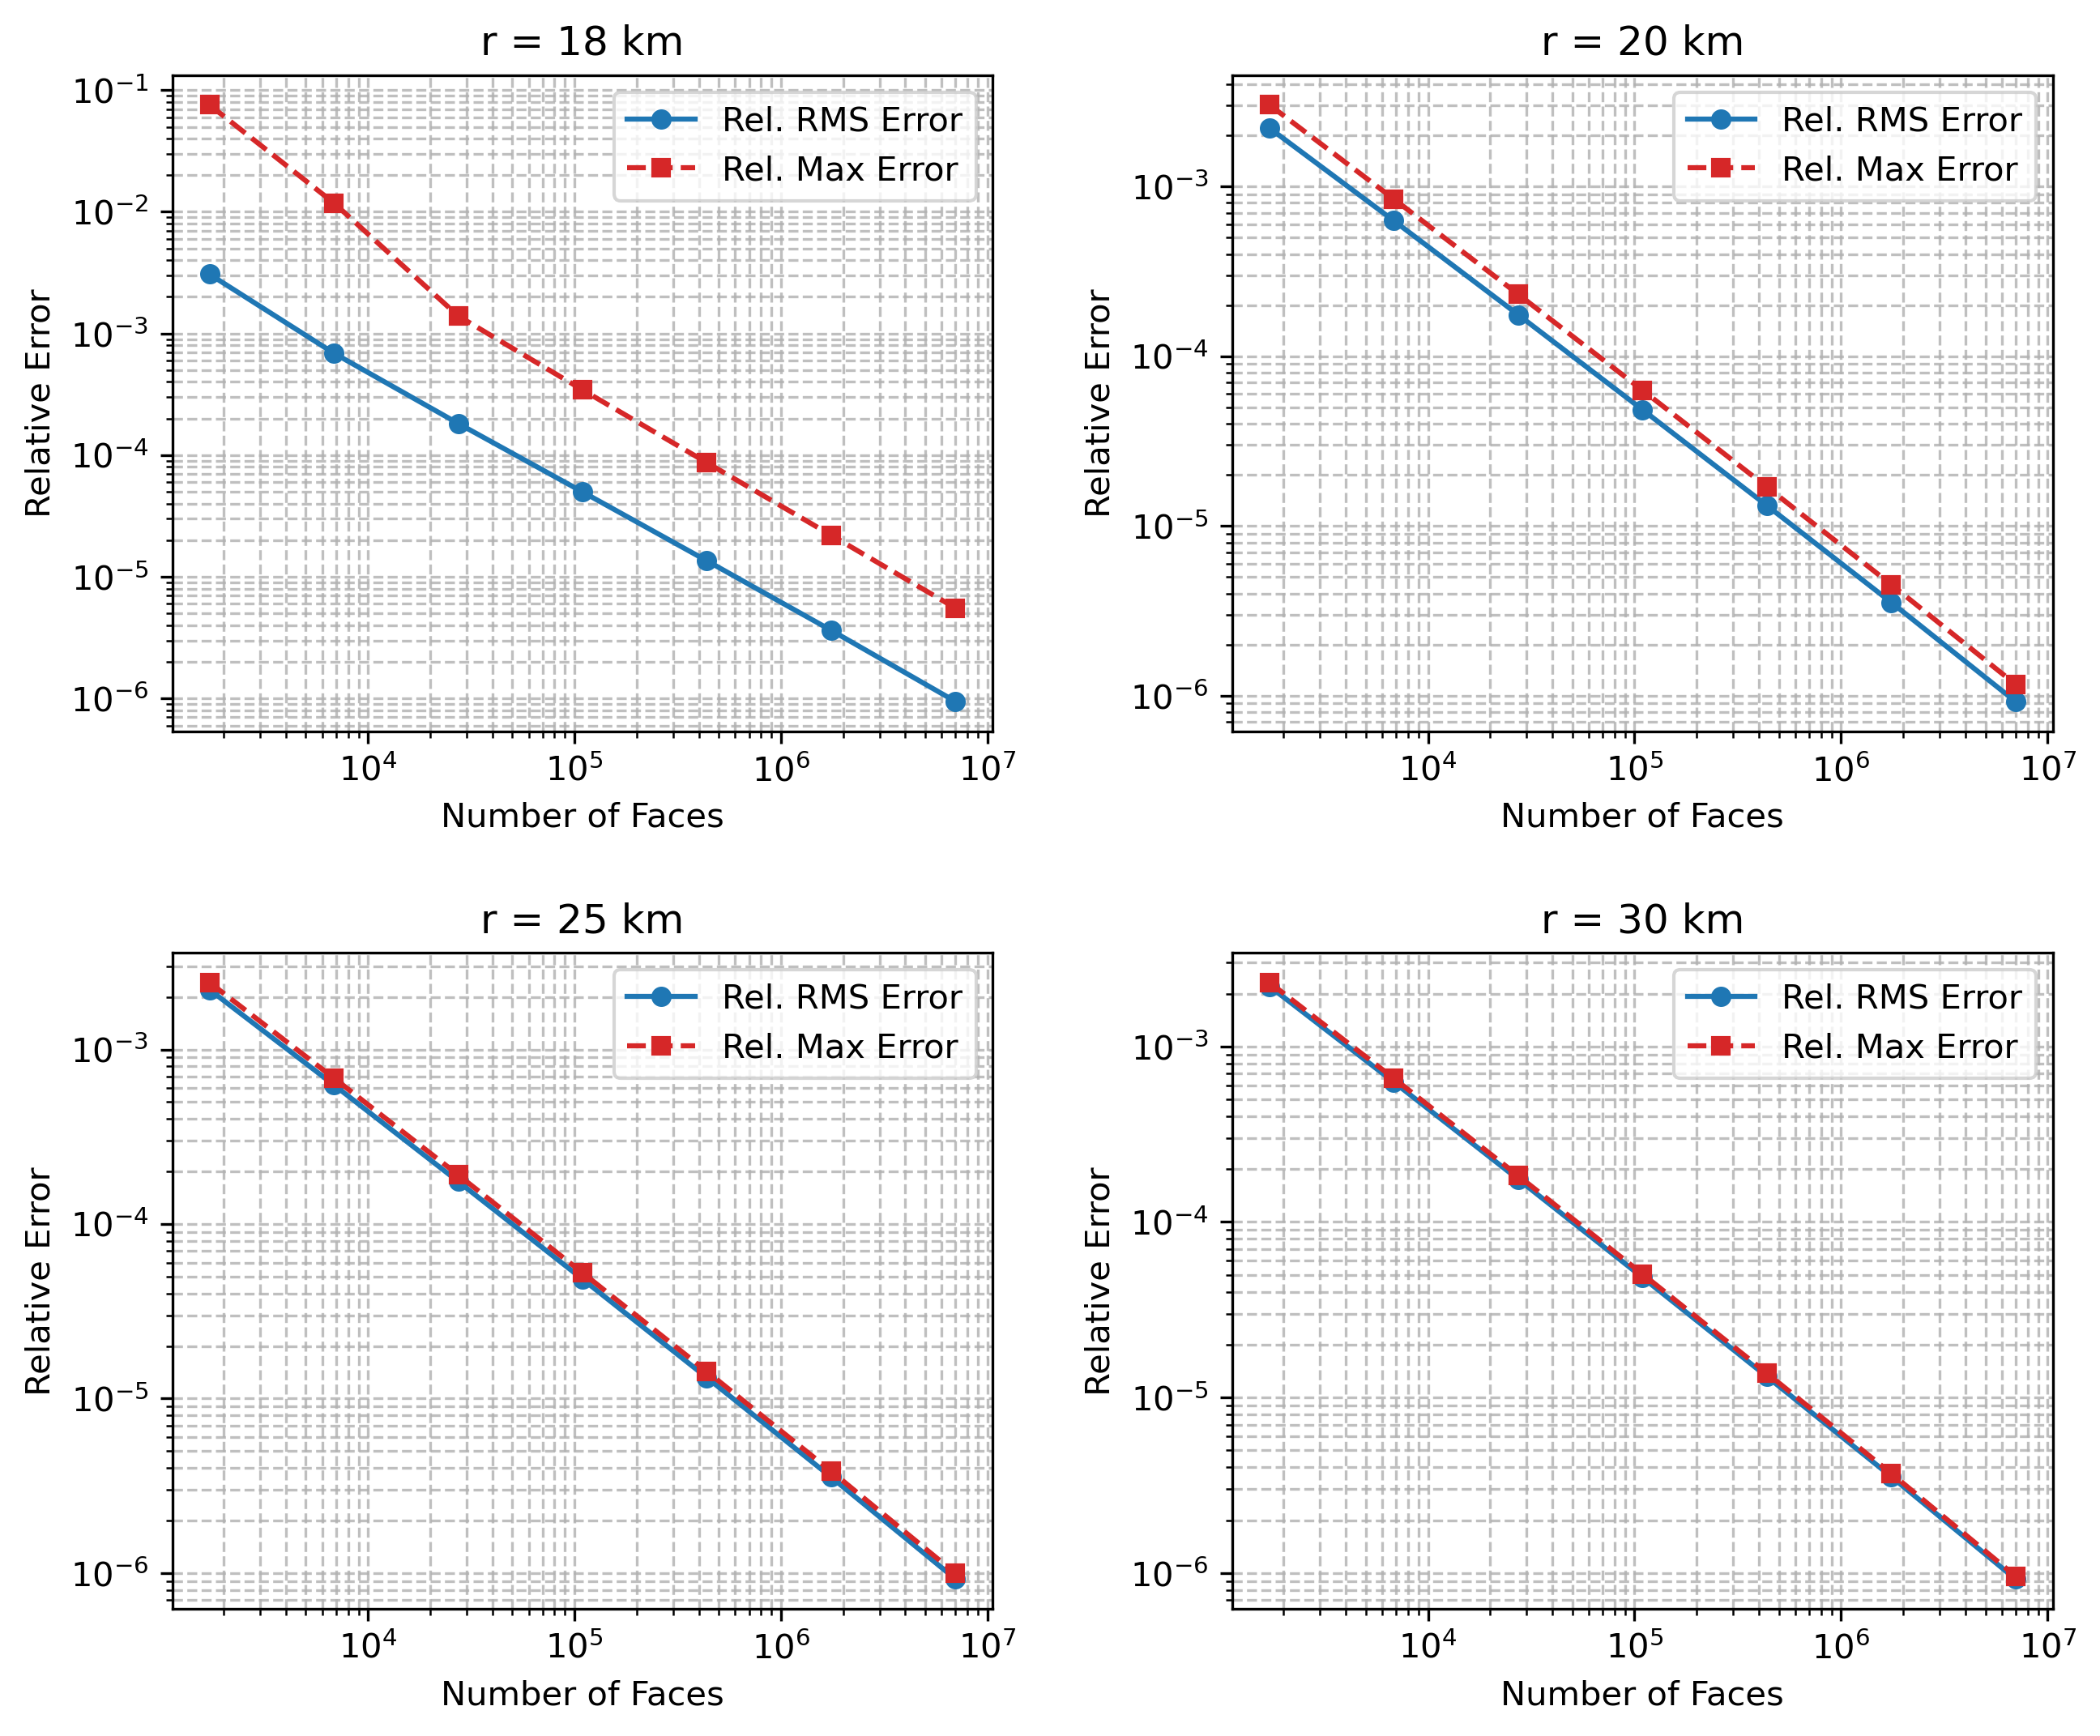

In [14]:
# Plot convergence: one subplot per radius

fig, axes = plt.subplots(2, 2, figsize=(9, 7.5), dpi=300)
axes = np.array(axes).reshape(-1)

n_faces_list = [lvl_summary['n_faces'] for lvl_summary in converg_summary]
rel_rms_matrix = np.array([lvl_summary['rel_rms'] for lvl_summary in converg_summary])
rel_max_matrix = np.array([lvl_summary['rel_max'] for lvl_summary in converg_summary])

for i, r in enumerate(radii):
    ax = axes[i]
    rms_vals = rel_rms_matrix[:, i]
    max_vals = rel_max_matrix[:, i]

    ax.loglog(n_faces_list, rms_vals,
              marker='o', linestyle='-', color='tab:blue',
              label='Rel. RMS Error', markersize=5)
    ax.loglog(n_faces_list, max_vals,
              marker='s', linestyle='--', color='tab:red',
              label='Rel. Max Error', markersize=5)

    ax.set_title(f'r = {r} km', fontsize=12)
    ax.grid(True, which="both", ls="--", alpha=0.8)
    ax.set_xlabel('Number of Faces')
    ax.set_ylabel('Relative Error')
    ax.legend()

plt.tight_layout(pad=2.0)
fig.savefig('greenthirdid_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

Preparing error plot for subdivision level 0...
Preparing error plot for subdivision level 1...
Preparing error plot for subdivision level 2...
Preparing error plot for subdivision level 3...


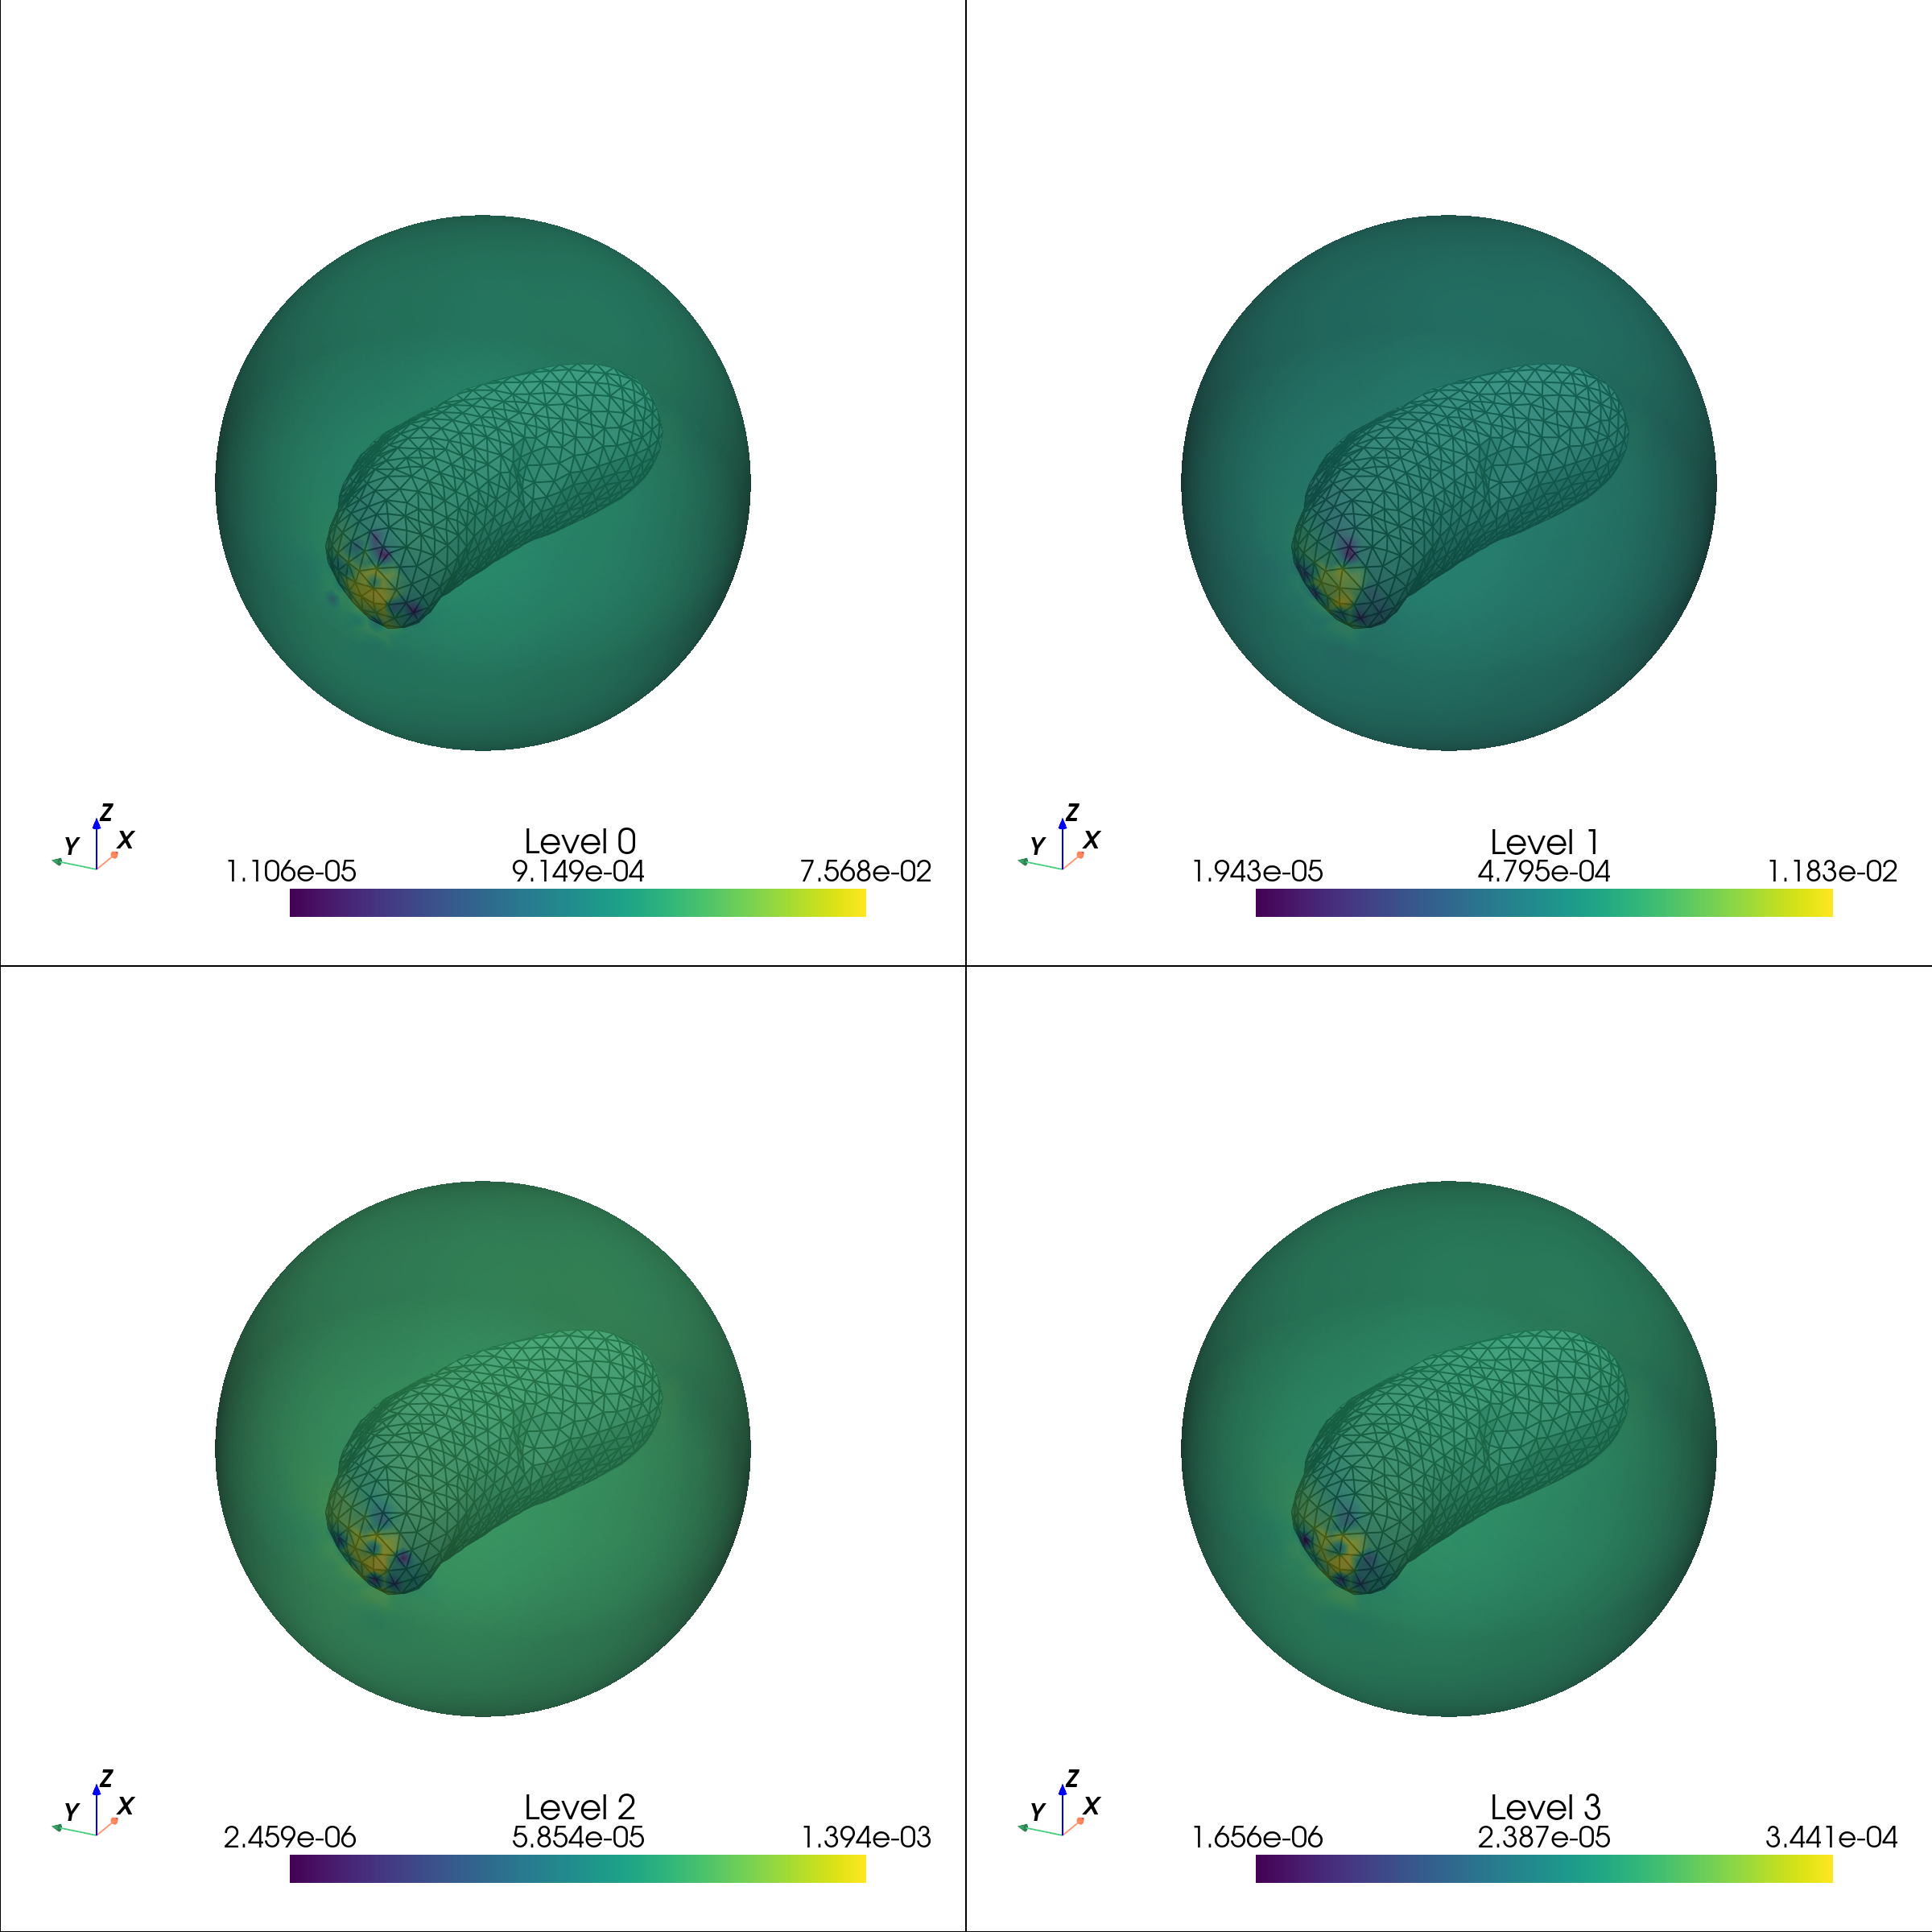

In [15]:
# Visualize pointwise relative error on r = 18 km sphere across refinement levels
plot_levels = [0, 1, 2, 3]  # Choose 4 levels for 2x2 grid

r_target = radii[0]  # 18 km
pts_18km = eval_pts_Rs[0]
V_exact_18 = V_exact_Rs[0]

target_sphere = pv.Icosphere(radius=r_target, nsub=icosph_level)

pl = pv.Plotter(shape=(2, 2), border=True, 
                window_size=[800, 800], image_scale=3)

for plot_idx, level in enumerate(plot_levels):
    print(f"Preparing error plot for subdivision level {level}...")
    
    # Reconstruct refined mesh
    eros_sub = eros_base.subdivide(level, subfilter='linear')
    
    # Extract face data
    face_centers = eros_sub.cell_centers().points
    face_normals = eros_sub.face_normals
    face_areas = eros_sub.compute_cell_sizes()["Area"]
    
    # Compute exact field on face centers
    V_face, gx_face, gy_face, gz_face, *_ = VecWerSch_numba(face_centers, Verts, Faces, rho)
    g_face = np.column_stack((gx_face, gy_face, gz_face))
    
    # Evaluate Green's potential on r=18 km sphere
    V_green_18 = green_third_identity_potential_numba(
        face_centers, face_normals, face_areas, V_face, g_face, pts_18km
    )
    
    # Compute pointwise relative error
    rel_error = np.abs(V_green_18 - V_exact_18) / np.abs(V_exact_18)
    target_sphere[f'level{level}'] = rel_error
    
    # Plot Eros shape model
    pl.subplot(plot_idx // 2, plot_idx % 2)
    pl.add_mesh(eros_base, color=None, show_edges=True, line_width=2)
    
    # Add the scaled unit sphere with errors
    # pl.add_mesh(target_sphere.copy(deep=False), scalars=f'level{level}', cmap='viridis',
    #             style='points', render_points_as_spheres=True, point_size=14,
    #             opacity=1.0, log_scale=True, show_edges=False, show_scalar_bar=False)

    pl.add_mesh(target_sphere.copy(deep=False), scalars=f'level{level}', cmap='viridis',
                style='surface',
                opacity=0.75, log_scale=True, show_edges=False, show_scalar_bar=False)
    
    # Add scalar bar
    pl.add_scalar_bar(title=f'Level {level}', title_font_size=14, 
                      label_font_size=12, n_labels=3, position_x=0.3, fmt='%.3e')
    
    # Set camera position
    pl.camera_position = [(-100, -50, 50), (0, 0, 0), (0, 0, 1)]

    # Add XYZ axes
    pl.add_axes(label_size=(0.1/3, 0.1/3))

pl.link_views()
pl.show()
pl.screenshot("greenthirdid_convergence_r18km.png");